In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [4]:
df =pd.read_csv("insurance.csv")

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='age', ylabel='Count'>

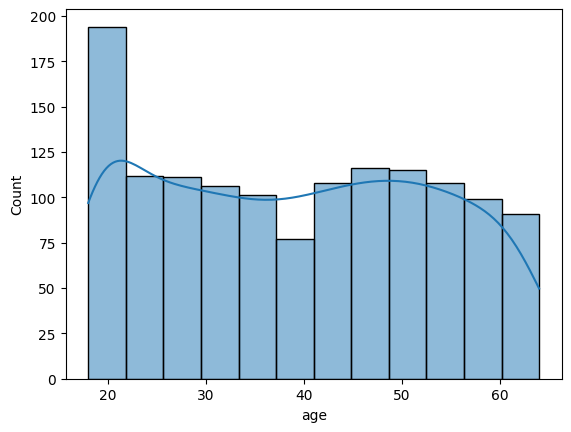

In [7]:
sns.histplot(data=df,x='age',kde=True)

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# info =df.info()

In [9]:
 
for col in df.columns.to_list():
    print(f" {df[col].nunique()} => {col}")
 

 47 => age
 2 => sex
 548 => bmi
 6 => children
 2 => smoker
 4 => region
 1337 => charges


In [10]:
df['region'].value_counts()


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

<Axes: >

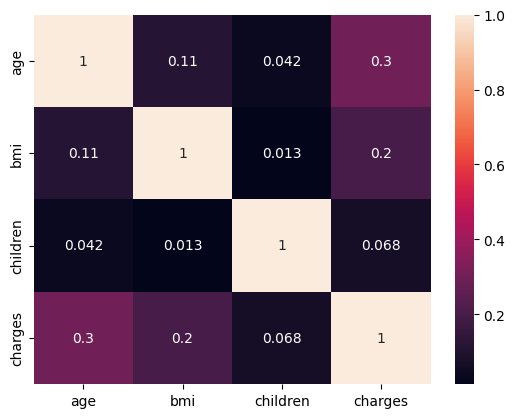

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
df['sex']=df['sex'].map({'male':0,'female':1})

In [16]:
df['smoker']=df['smoker'].map({'no':0,'yes':1})

In [17]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [18]:
df=pd.get_dummies(df,columns=['region'], drop_first=False)

In [20]:
df=df.astype(int)

<Axes: xlabel='bmi', ylabel='Count'>

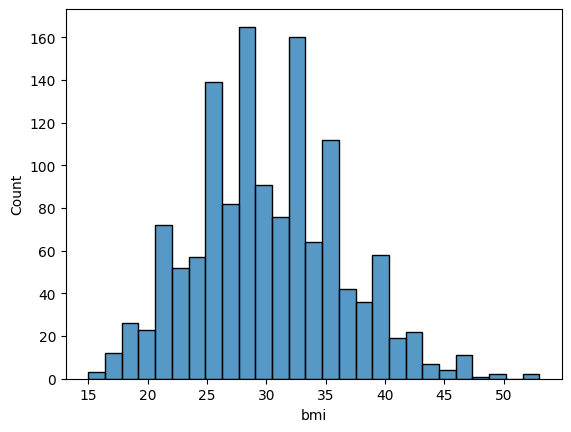

In [22]:
sns.histplot(data=df['bmi'])

In [24]:
df['bmi_category']=pd.cut(
    df['bmi'],
    bins=[0,18.5,24.9,29.9, float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [26]:
df=pd.get_dummies(df,columns=['bmi_category'], drop_first=False)

In [28]:
df=df.astype(int)

In [30]:
from sklearn.preprocessing import StandardScaler
cols =['age','bmi','children']
scaler =StandardScaler()
df[cols]=scaler.fit_transform(df[cols])

In [36]:
from scipy.stats import pearsonr
selected_features=['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'bmi_category_Underweight',
 'bmi_category_Normal',
 'bmi_category_Overweight',
 'bmi_category_Obese']
correlations ={
    feature : pearsonr(df[feature],df['charges'])[0]
    for feature in selected_features
}
correlation_df =pd.DataFrame(list(correlations.items()),columns=["Feature","Pearson Correlation"])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)
                                                                 

,Feature,Pearson Correlation
4,smoker,0.787251
0,age,0.299009
12,bmi_category_Obese,0.199533
2,bmi,0.196188
7,region_southeast,0.073981
3,children,0.067999
5,region_northeast,0.006350
6,region_northwest,-0.039905
8,region_southwest,-0.043210
9,bmi_category_Underweight,-0.050484


In [33]:
df.columns.to_list()

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'charges',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'bmi_category_Underweight',
 'bmi_category_Normal',
 'bmi_category_Overweight',
 'bmi_category_Obese']